# Car-Sharing Service

The problem setup, relevant codes and the required dataset have been sourced from [AI Search Algorithms for Smart Mobility - By Alaa Khamis and Yinan Wang](https://smartmobilityalgorithms.github.io/book/content/PeopleMobilityProblems/carsharing/CarSharing.html)

In [1]:
import pandas as pd
from smart_mobility_utilities.poi import poi
from smart_mobility_utilities.poi import drawRouteOrder
from smart_mobility_utilities.problem import ordOne_crossover, swap_mutation
from copy import deepcopy
import random
from heapq import nlargest
import matplotlib.pyplot as plt
from statistics import mean 

## Data

The passenger mobility task is distributed amongst three Shared Driving Vehicles (SDVs). The map below designates the pickp-up locations for each SDV; purple markers for the first SDV, green for the second and orange for the third.  

In [2]:
# Import location data
depots = pd.read_csv("carshare_depot.csv")
depot_nodes = [poi(row['address'],'canada',row['lat'],row['lng']) for index, row in depots.iterrows()]
pickups = pd.read_csv("carshare_origin.csv")
pickup_nodes = [poi(row['address'],'canada',row['lat'],row['lng']) for index, row in pickups.iterrows()]
dropoffs = pd.read_csv("carshare_dest.csv")
dropoff_nodes = [poi(row['address'],'canada',row['lat'],row['lng']) for index, row in dropoffs.iterrows()]

# Import a pre-calculated trip distance matrix
# These distances are based off of an osrm routing
tm = pd.read_csv("trip_matrix.csv").values
trip_matrix = {}
all_points = depot_nodes + pickup_nodes + dropoff_nodes
for point in all_points:
    i = all_points.index(point)
    trip_matrix[point] = {}
    for point2 in all_points:
        j = all_points.index(point2)
        trip_matrix[point][point2] = tm[i][j+1]
        
from folium import Map, Marker, PolyLine, Icon
m = Map(location=pickup_nodes[0].coordinates[::-1], zoom_start=11)

first_vehicle_index = [0,1,5,4]
second_vehicle_index = [2,3,6]
third_vehicle_index = [7,8,9]

first_pickups = [x for x in pickup_nodes if pickup_nodes.index(x) in first_vehicle_index]
first_dropoffs = [x for x in dropoff_nodes if dropoff_nodes.index(x) in first_vehicle_index]
second_pickups = [x for x in pickup_nodes if pickup_nodes.index(x) in second_vehicle_index]
second_dropoffs = [x for x in dropoff_nodes if dropoff_nodes.index(x) in second_vehicle_index]
third_pickups = [x for x in pickup_nodes if pickup_nodes.index(x) in third_vehicle_index]
third_dropoffs = [x for x in dropoff_nodes if dropoff_nodes.index(x) in third_vehicle_index]

for x in pickup_nodes:
    if pickup_nodes.index(x) in third_vehicle_index:
        c = "orange"
    if pickup_nodes.index(x) in second_vehicle_index:
        c  = "green"
    if pickup_nodes.index(x) in first_vehicle_index:
        c = "purple"
    Marker(location=x.coordinates[::-1], popup=x.coordinates, icon=Icon(color=c)).add_to(m)

# for x in depot_nodes:
#     Marker(location=x.coordinates[::-1], popup=x.coordinates, icon=Icon(color="black")).add_to(m)

m


## Simple GA Class

In [3]:
class CarSharingSolver_SGA:
    def __init__(
        self,
        depot_nodes,
        pickup_nodes,
        dropoff_nodes,
        trip_matrix,
        pop_size,
        iterations,
        num_parents,
        mutation_prob,
        crossover_prob,
        pre_avoid = [],
        post_avoid = []
    ):

        self.pickups = pickup_nodes
        self.depots = depot_nodes
        self.dropoffs = dropoff_nodes
        self.trip_matrix = trip_matrix
        self.pop_size = pop_size
        self.iterations = iterations
        self.num_parents = num_parents
        self.mutation_prob = mutation_prob
        self.crossover_prob = crossover_prob
        self.population = None
        self.costs = None
        self.states = []       
        self.solution = None
        self.solution_cost = None
        self.pre_avoid = pre_avoid
        self.post_avoid = post_avoid

    def crossover(parent1, parent2):
        return ordOne_crossover(parent1, parent2)

    def mutation(permutation):
        return swap_mutation(permutation)

    # Find the closest depots for start and end, avoiding ones that are already filled
    def find_depots(self, route):
        start = route[0]
        end = route[-1]
        depots = deepcopy(self.depots)
        tmp_depots = deepcopy(depots)
        [depots.pop(depots.index(x)) for x in self.pre_avoid if x in depots]
        distances_to_start = [self.trip_matrix[x][start] for x in depots]
        [depots.pop(depots.index(x)) for x in self.post_avoid if x in depots]
        distances_from_end = [self.trip_matrix[end][x] for x in depots]
        start_depot = tmp_depots[distances_to_start.index(min(distances_to_start))]
        end_depot = tmp_depots[distances_from_end.index(min(distances_from_end))]
        route = [start_depot] + route + [end_depot]
        return route

    def random_solution(self):
        route = []
        can_visit = deepcopy(self.pickups)
        for i in range(len(self.pickups)):
            # select a random pickup location
            random_pickup = random.choice(can_visit)
            route.append(random_pickup)
            can_visit.pop(can_visit.index(random_pickup))

        # now we can choose the depot closest to starting and ending locations
        route = self.find_depots(route)
        return route

    def expand_route(self, route):
        actual_route = []
        for stop in route:
            if stop not in self.pickups:
                # It is a depot
                actual_route.append(stop)
                continue
            actual_route.append(stop)
            drop = self.dropoffs[self.pickups.index(stop)]
            actual_route.append(drop)
        return actual_route

    def fitness(self, solutions):
        result = []
        for vehicle_route in solutions:
            # We need to expand the routes into pickup-dropoffs to calculate actual cost
            expanded_route = self.expand_route(vehicle_route)
            total = 0
            for stop, next_stop in zip(expanded_route[:-1], expanded_route[1:]):
                if stop in self.pickups and next_stop in self.dropoffs:
                    cost_factor = 0.5
                else:
                    cost_factor = -0.3
                total += cost_factor * self.trip_matrix[stop][next_stop]
            result.append(round(total,2))
        return result
    
    def initial_population(self):
        self.population = [
            self.random_solution()
            for _ in range(self.pop_size)
        ]
        self.costs = self.fitness(self.population)

    # Single vehicle, genetic algorithm
    def run(self):
        # Check that initial population exists:
        if self.population:
            # Show some information
            print("Initial Population costs:")
            print(self.costs)
        else:
            raise Exception("Population not initialized.")
        
        for _ in range(self.iterations):
            self.costs = self.fitness(self.population)
            self.states.append(max(self.costs))
            # Select the parents, we want to maximize the profit
            parents = nlargest(self.num_parents,self.population, key=lambda x: self.costs[self.population.index(x)])
            # Need to remove depots from the routes
            parents = [x[1:-1] for x in parents]
            offspring = []
            new_population = []
            for p1, p2 in zip(parents[:len(parents)//2],parents[len(parents)//2:]):
                # Crossover probability
                if random.random() < self.crossover_prob:
                    offspring.append(CarSharingSolver_SGA.crossover(p1,p2))
                    offspring.append(CarSharingSolver_SGA.crossover(p2,p1))
                else:
                    offspring.append(p1)
                    offspring.append(p2)
            for child in offspring:
                if random.random() < self.mutation_prob:
                    new_population.append(CarSharingSolver_SGA.mutation(child))
                else:
                    new_population.append(child)
            new_population.extend(parents)
            self.population = [self.find_depots(route) for route in new_population]

        # Show best solution
        self.costs = self.fitness(self.population)
        self.states.append(max(self.costs))
        self.solution = max(self.population,key= lambda x: self.costs[self.population.index(x)])
        self.solution_cost = self.costs[self.population.index(self.solution)]
        self.solution = self.expand_route(self.solution)
        print("Best Solution:", self.solution)
        print("Best Solution Profits:", self.solution_cost, "\n")
        

    def visualize_solution(self, m=None, route_color="red", prefix=""):
        # define marker colors
        colors = []
        for stop in self.solution:
            if stop in self.depots:
                colors.append('blue')
            if stop in self.pickups:
                colors.append('green')
            if stop in self.dropoffs:
                colors.append('red')
        return drawRouteOrder(
            [x.coordinates[::-1] for x in self.solution],
            self.solution,
            range(1,len(self.solution)+1), 
            colors=colors, route_color=route_color, m=m, prefix=prefix)
    
    def visualize_graph(self):
        plt.plot(self.states)
        plt.xlabel("Iterations")
        plt.ylabel("Profit")
        plt.show()   

## Solution - SGA
The steps to do this are as follows:
1. Generate the best solution for the first vehicle and its subset of pickups.
2. Remove the first vehicle's used depots as viable depots for the second vehicle.
3. Generate the best solution for the second vehicle and its subset of pickups.
3. Remove the first and second vehicle's used depots as viable depots for the third vehicle.
3. Generate the best solution for the third vehicle and its subset of pickups.

In [4]:
%%time

pop_size = 4
iterations = 300
num_parents = 2
mutation_prob = 0.3
crossover_prob = 0.7

# First vehicle best solution
first_solver_SGA = CarSharingSolver_SGA(
    depot_nodes, 
    first_pickups, 
    first_dropoffs, 
    trip_matrix, 
    pop_size, 
    iterations, 
    num_parents, 
    mutation_prob, 
    crossover_prob)

# Initialize the population
first_solver_SGA.initial_population()
first_solver_SGA.run()

# Second vehicle best solution, with depots removed
second_solver_SGA = CarSharingSolver_SGA(
    depot_nodes, 
    second_pickups, 
    second_dropoffs, 
    trip_matrix, 
    pop_size, 
    iterations, 
    num_parents, 
    mutation_prob, 
    crossover_prob,
    pre_avoid = [first_solver_SGA.solution[0]],
    post_avoid = [first_solver_SGA.solution[-1]])

# Initialize the population
second_solver_SGA.initial_population()
second_solver_SGA.run()

# Third vehicle best solution, with depots removed
third_solver_SGA = CarSharingSolver_SGA(
    depot_nodes, 
    third_pickups, 
    third_dropoffs, 
    trip_matrix, 
    pop_size, 
    iterations, 
    num_parents, 
    mutation_prob, 
    crossover_prob,
    pre_avoid = [second_solver_SGA.solution[0], first_solver_SGA.solution[0]],
    post_avoid = [second_solver_SGA.solution[-1],first_solver_SGA.solution[-1]])

# Initialize the population
third_solver_SGA.initial_population()
third_solver_SGA.run()

print("Total profit SGA: ",round(first_solver_SGA.solution_cost+second_solver_SGA.solution_cost+third_solver_SGA.solution_cost,2),"\n")

Initial Population costs:
[7847.78, 7847.78, 5415.71, 3947.48]
Best Solution: [Name: 93 ID: 4035051033, Name: 565 ID: 803149738, Name: 31 ID: 803176775, Name: Toronto Transit Commission ID: 32052212, Name: 2575 ID: 43805702, Name: Bayview Avenue ID: 2525612330, Name: 15 ID: 803174456, Name: 799 ID: 401062600, Name: 49 ID: 804609495, Name: 93 ID: 4035051033]
Best Solution Profits: 8480.66 

Initial Population costs:
[4440.14, 1238.42, 3600.5, 4745.48]
Best Solution: [Name: Scott Street ID: 1288945058, Name: 90 ID: 804610960, Name: Continental Tower ID: 103953736, Name: 444 ID: 4035049080, Name: 32 ID: 66412324, Name: St. Barnabas Anglican Church ID: 43811604, Name: Royal Bank Plaza North Tower ID: 27767624, Name: Scott Street ID: 1288945058]
Best Solution Profits: 4745.48 

Initial Population costs:
[404.47, -1704.74, 519.76, 404.47]
Best Solution: [Name: Optima ID: 96156270, Name: Bloor Street West ID: 2286883372, Name: 40 ID: 72376319, Name: The Squire and Firkin ID: 2287594369, Name:

## Adaptive GA Class

Adaptive GA is implememted by controlling the mutation probability based on the average fitness value of the past generations. 

In [5]:
class CarSharingSolver_AGA:
    def __init__(
        self,
        depot_nodes,
        pickup_nodes,
        dropoff_nodes,
        trip_matrix,
        pop_size,
        iterations,
        num_parents,
        mutation_prob_const1,
        mutation_prob_const2,
        mutation_prob_rate,
        crossover_prob,
        pre_avoid = [],
        post_avoid = []
    ):

        self.pickups = pickup_nodes
        self.depots = depot_nodes
        self.dropoffs = dropoff_nodes
        self.trip_matrix = trip_matrix
        self.pop_size = pop_size
        self.iterations = iterations
        self.num_parents = num_parents
        self.mutation_prob = mutation_prob_const1
        self.mutation_prob_const1 = mutation_prob_const1
        self.mutation_prob_const2 = mutation_prob_const2
        self.mutation_prob_rate = mutation_prob_rate
        self.crossover_prob = crossover_prob
        self.population = None
        self.costs = None
        self.states = []  
        self.mutation_prob_adapt = []
        self.mutation_count = []
        self.solution = None
        self.solution_cost = None
        self.pre_avoid = pre_avoid
        self.post_avoid = post_avoid

    def crossover(parent1, parent2):
        return ordOne_crossover(parent1, parent2)

    def mutation(permutation):
        return swap_mutation(permutation)

    # Find the closest depots for start and end, avoiding ones that are already filled
    def find_depots(self, route):
        start = route[0]
        end = route[-1]
        depots = deepcopy(self.depots)
        tmp_depots = deepcopy(depots)
        [depots.pop(depots.index(x)) for x in self.pre_avoid if x in depots]
        distances_to_start = [self.trip_matrix[x][start] for x in depots]
        [depots.pop(depots.index(x)) for x in self.post_avoid if x in depots]
        distances_from_end = [self.trip_matrix[end][x] for x in depots]
        start_depot = tmp_depots[distances_to_start.index(min(distances_to_start))]
        end_depot = tmp_depots[distances_from_end.index(min(distances_from_end))]
        route = [start_depot] + route + [end_depot]
        return route

    def random_solution(self):
        route = []
        can_visit = deepcopy(self.pickups)
        for i in range(len(self.pickups)):
            # select a random pickup location
            random_pickup = random.choice(can_visit)
            route.append(random_pickup)
            can_visit.pop(can_visit.index(random_pickup))

        # now we can choose the depot closest to starting and ending locations
        route = self.find_depots(route)
        return route

    def expand_route(self, route):
        actual_route = []
        for stop in route:
            if stop not in self.pickups:
                # It is a depot
                actual_route.append(stop)
                continue
            actual_route.append(stop)
            drop = self.dropoffs[self.pickups.index(stop)]
            actual_route.append(drop)
        return actual_route

    def fitness(self, solutions):
        result = []
        for vehicle_route in solutions:
            # We need to expand the routes into pickup-dropoffs to calculate actual cost
            expanded_route = self.expand_route(vehicle_route)
            total = 0
            for stop, next_stop in zip(expanded_route[:-1], expanded_route[1:]):
                if stop in self.pickups and next_stop in self.dropoffs:
                    cost_factor = 0.5
                else:
                    cost_factor = -0.3
                total += cost_factor * self.trip_matrix[stop][next_stop]
            result.append(round(total,2))
        return result
    
    def initial_population(self):
        self.population = [
            self.random_solution()
            for _ in range(self.pop_size)
        ]
        self.costs = self.fitness(self.population)

    # Single vehicle, genetic algorithm
    def run(self):
        # Check that initial population exists:
        if self.population:
            # Show some information
            print("Initial Population costs:")
            print(self.costs)
        else:
            raise Exception("Population not initialized.")
        
        mutation_count = 0
        
        for _ in range(self.iterations):
            self.costs = self.fitness(self.population)
            self.states.append(max(self.costs))

            
            # Select the parents, we want to maximize the profit
            parents = nlargest(self.num_parents,self.population, key=lambda x: self.costs[self.population.index(x)])
            # Need to remove depots from the routes
            parents = [x[1:-1] for x in parents]
            offspring = []
            new_population = []
            for p1, p2 in zip(parents[:len(parents)//2],parents[len(parents)//2:]):
                # Crossover probability
                if random.random() < self.crossover_prob:
                    offspring.append(CarSharingSolver_AGA.crossover(p1,p2))
                    offspring.append(CarSharingSolver_AGA.crossover(p2,p1))
                else:
                    offspring.append(p1)
                    offspring.append(p2)
                    
            for child in offspring:
                
                # implementing adaptive mutation probability
                offspring_gene = [self.find_depots(child)]
                offspring_fitness = self.fitness(offspring_gene)
                
                if offspring_fitness <= mean(self.states) :
                    self.mutation_prob = (1 + mutation_prob_rate) * self.mutation_prob
                    if self.mutation_prob >= self.mutation_prob_const1:
                        self.mutation_prob = self.mutation_prob_const1
                        
                if offspring_fitness > mean(self.states) :
                    self.mutation_prob = (1 - mutation_prob_rate) * self.mutation_prob
                    if self.mutation_prob <= self.mutation_prob_const2:
                        self.mutation_prob = self.mutation_prob_const2
                
                if random.random() < self.mutation_prob:
                    mutation_count += 1
                    new_population.append(CarSharingSolver_AGA.mutation(child))

                else:
                    new_population.append(child)
                    
            self.mutation_prob_adapt.append(self.mutation_prob)                    
            self.mutation_count.append(mutation_count)   
            
            new_population.extend(parents)
            self.population = [self.find_depots(route) for route in new_population]

        # Show best solution
        self.costs = self.fitness(self.population)
        self.states.append(max(self.costs))
        self.solution = max(self.population,key= lambda x: self.costs[self.population.index(x)])
        self.solution_cost = self.costs[self.population.index(self.solution)]
        self.solution = self.expand_route(self.solution)
        print("Best Solution:", self.solution)
        print("Best Solution Profits:", self.solution_cost, "\n")
        

    def visualize_solution(self, m=None, route_color="red", prefix=""):
        # define marker colors
        colors = []
        for stop in self.solution:
            if stop in self.depots:
                colors.append('blue')
            if stop in self.pickups:
                colors.append('green')
            if stop in self.dropoffs:
                colors.append('red')
        return drawRouteOrder(
            [x.coordinates[::-1] for x in self.solution],
            self.solution,
            range(1,len(self.solution)+1), 
            colors=colors, route_color=route_color, m=m, prefix=prefix)
    
    def visualize_graph(self):
        plt.plot(self.states)
        plt.xlabel("Iterations")
        plt.ylabel("Profit")
        plt.show()    
        
    def visualize_mutation_adapt(self):
        fig, ax1 = plt.subplots()
        ax2 = ax1.twinx()
        ax1.plot(self.mutation_prob_adapt, 'g-')
        ax2.plot(self.mutation_count, 'b-')

        ax1.set_xlabel("Iterations")
        ax1.set_ylabel("Mutation Probability", color='g')
        ax1.set_ylim(0,1)
        ax2.set_ylabel('Successful Mutations', color='b')
        
        plt.show() 
        


## Solution - Adaptive GA 

Same process is followed as SGA to obtain solution for adaptive GA


In [8]:
%%time

pop_size = 4
iterations = 250
num_parents = 2
mutation_prob_rate = 0.01
mutation_prob_const1 = 0.5
mutation_prob_const2 = 0.2
crossover_prob = 0.7

# First vehicle best solution
first_solver_AGA = CarSharingSolver_AGA(
    depot_nodes, 
    first_pickups, 
    first_dropoffs, 
    trip_matrix, 
    pop_size, 
    iterations, 
    num_parents, 
    mutation_prob_const1,
    mutation_prob_const2,
    mutation_prob_rate,
    crossover_prob)

# Initialize the population
first_solver_AGA.initial_population()
first_solver_AGA.run()

# Second vehicle best solution, with depots removed
second_solver_AGA = CarSharingSolver_AGA(
    depot_nodes, 
    second_pickups, 
    second_dropoffs, 
    trip_matrix, 
    pop_size, 
    iterations, 
    num_parents, 
    mutation_prob_const1,
    mutation_prob_const2,
    mutation_prob_rate,
    crossover_prob,
    pre_avoid = [first_solver_AGA.solution[0]],
    post_avoid = [first_solver_AGA.solution[-1]])

# Initialize the population
second_solver_AGA.initial_population()
second_solver_AGA.run()

# Third vehicle best solution, with depots removed
third_solver_AGA = CarSharingSolver_AGA(
    depot_nodes, 
    third_pickups, 
    third_dropoffs, 
    trip_matrix, 
    pop_size, 
    iterations, 
    num_parents, 
    mutation_prob_const1,
    mutation_prob_const2,
    mutation_prob_rate,
    crossover_prob,
    pre_avoid = [second_solver_AGA.solution[0], first_solver_AGA.solution[0]],
    post_avoid = [second_solver_AGA.solution[-1],first_solver_AGA.solution[-1]])

# Initialize the population
third_solver_AGA.initial_population()
third_solver_AGA.run()

print("Total profit AGA: ",round(first_solver_AGA.solution_cost+second_solver_AGA.solution_cost+third_solver_AGA.solution_cost,2), "\n")

Initial Population costs:
[7365.02, 5415.71, 6387.02, 6442.76]
Best Solution: [Name: 93 ID: 4035051033, Name: 565 ID: 803149738, Name: 31 ID: 803176775, Name: Toronto Transit Commission ID: 32052212, Name: 2575 ID: 43805702, Name: Bayview Avenue ID: 2525612330, Name: 15 ID: 803174456, Name: 799 ID: 401062600, Name: 49 ID: 804609495, Name: 93 ID: 4035051033]
Best Solution Profits: 8480.66 

Initial Population costs:
[4745.48, 1586.45, 1586.45, 3600.5]
Best Solution: [Name: Scott Street ID: 1288945058, Name: 90 ID: 804610960, Name: Continental Tower ID: 103953736, Name: 444 ID: 4035049080, Name: 32 ID: 66412324, Name: St. Barnabas Anglican Church ID: 43811604, Name: Royal Bank Plaza North Tower ID: 27767624, Name: Scott Street ID: 1288945058]
Best Solution Profits: 4745.48 

Initial Population costs:
[-1704.74, -1704.74, -54.32, 519.76]
Best Solution: [Name: Optima ID: 96156270, Name: Bloor Street West ID: 2286883372, Name: 40 ID: 72376319, Name: The Squire and Firkin ID: 2287594369, Nam

## AGA : Adaptive Mutation Probability

The change in mutation probability of the first child after crossover is shown below. The mutation probability decreases if the offspring is better than the average population and the mutation probability increases if the offspring is worse than the average population. The maximum and minimum possible probabilities are limited by parameters _mutation_prob_const1 and mutation_prob_const2_ respectively. 

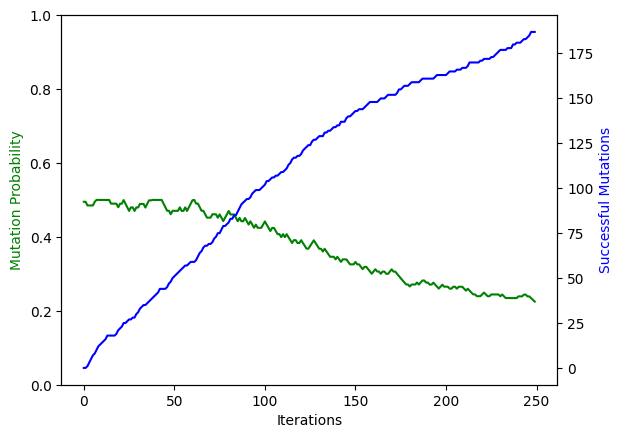

In [9]:
first_solver_AGA.visualize_mutation_adapt()

## Car Sharing Routes (Genetic Algorithm)

### SGA Route

In [10]:
first_map_SGA = first_solver_SGA.visualize_solution(route_color="blue",prefix="A")
second_map_SGA = second_solver_SGA.visualize_solution(route_color="green", m = first_map_SGA, prefix="B")
third_map_SGA = third_solver_SGA.visualize_solution(route_color="red", m=second_map_SGA, prefix="C")
third_map_SGA

***

### AGA Route

In [11]:
first_map_AGA = first_solver_AGA.visualize_solution(route_color="blue",prefix="A")
second_map_AGA = second_solver_AGA.visualize_solution(route_color="green", m = first_map_AGA, prefix="B")
third_map_AGA = third_solver_AGA.visualize_solution(route_color="red", m=second_map_AGA, prefix="C")
third_map_AGA

## Swarm Intelligence 

### Particle Swarm Optimisation (PSO)

Below is the PSO algortihm implementation for the car sharing service. The permutation PSO is utilized where the 'velocity' component is considered as the generated routes. During each iteration update, the social and congnitive bias drive the new soultion (i.e. velocity).  

### PSO Class Definitions

In [12]:
class Particle():
    def __init__(self, route, cost):
        self.route = route
        self.cost = cost

class CarSharingSolverPSO:
    def __init__(
        self,
        adaptive,
        depot_nodes,
        pickup_nodes,
        dropoff_nodes,
        trip_matrix,
        pop_size,  # population per swarm
        iterations,
        cognitive_bias,
        social_bias,
        pre_avoid = [],
        post_avoid = []
    ):

        self.pickups = pickup_nodes
        self.depots = depot_nodes
        self.dropoffs = dropoff_nodes
        self.trip_matrix = trip_matrix
        self.pop_size = pop_size
        self.iterations = iterations
        self.costs = None
        self.states = []       
        self.solution = None
        self.solution_cost = None
        self.pre_avoid = pre_avoid
        self.post_avoid = post_avoid
        self.particles = []
        self.particle_prev_route = []
        self.particle_best_route = []
        self.particle_best_cost = []
        self.particle_cognitive_bias = []
        self.bias_history = []
        self.gBest_cost = -float('inf')
        self.gBest_route = self.random_solution()
        self.cognitive_bias = cognitive_bias
        self.social_bias = social_bias
    
    def permute_route(route1, route2):
        return ordOne_crossover(route1, route2)
    
    def set_pBest(self):
        i = 0;
        for particle in self.particles:
            fitness_candidate = self.fitness(particle.route)
            if(self.particle_best_cost[i] < fitness_candidate):
                self.particle_best_cost[i] = fitness_candidate
                self.particle_best_route[i] = particle.route
                i += 1
                
    def set_gBest(self):
        self.gBest_cost = max(self.particle_best_cost)
        index_max = max(range(len(self.particle_best_cost)), key=self.particle_best_cost.__getitem__)
        self.gBest_route = self.particle_best_route[index_max]

        
    # Update each particles's permutation (velocity) based on previous result and 
    # cognitive/social bias. Permutation is achieved using the orderOne corssover 
    # algorithm in smart_mobility_utilities
    def update_particles(self):
        for i in range(1, len(self.particles)):
            route = self.particles[i].route
            route_nodepot = route[1:-1]
                 
            if adaptive:
                if self.fitness(route) <= mean(self.particle_best_cost):
                    self.particle_cognitive_bias[i] = 0.96*self.particle_cognitive_bias[i]
                    self.bias_history[i].append(self.particle_cognitive_bias[i])
                else:
                    self.bias_history[i].append(self.particle_cognitive_bias[i])                            
            
                 
            if random.random() < self.particle_cognitive_bias[i]:
                route_nodepot = CarSharingSolverPSO.permute_route(self.particle_best_route[i], self.particle_prev_route[i])

            if random.random() < self.social_bias:
                route_nodepot = CarSharingSolverPSO.permute_route(self.gBest_route, route)
                    
            route = self.find_depots(route_nodepot)
            update_particle = Particle(route, self.fitness(route))
            self.particles[i] = update_particle
            

    # Find the closest depots for start and end, avoiding ones that are already filled
    def find_depots(self, route):
        start = route[0]
        end = route[-1]
        depots = deepcopy(self.depots)
        tmp_depots = deepcopy(depots)
        [depots.pop(depots.index(x)) for x in self.pre_avoid if x in depots]
        distances_to_start = [self.trip_matrix[x][start] for x in depots]
        [depots.pop(depots.index(x)) for x in self.post_avoid if x in depots]
        distances_from_end = [self.trip_matrix[end][x] for x in depots]
        start_depot = tmp_depots[distances_to_start.index(min(distances_to_start))]
        end_depot = tmp_depots[distances_from_end.index(min(distances_from_end))]
        route = [start_depot] + route + [end_depot]
        return route

    def random_solution(self):
        route = []
        can_visit = deepcopy(self.pickups)
        for i in range(len(self.pickups)):
            # select a random pickup location
            random_pickup = random.choice(can_visit)
            route.append(random_pickup)
            can_visit.pop(can_visit.index(random_pickup))

        # now we can choose the depot closest to starting and ending locations
        route = self.find_depots(route)
        return route

    def expand_route(self, route):
        actual_route = []
        for stop in route:
            if stop not in self.pickups:
                # It is a depot
                actual_route.append(stop)
                continue
            actual_route.append(stop)
            drop = self.dropoffs[self.pickups.index(stop)]
            actual_route.append(drop)
        return actual_route

    def fitness(self, route):
        # We need to expand the routes into pickup-dropoffs to calculate actual cost
        expanded_route = self.expand_route(route)
        
        total = 0
        for stop, next_stop in zip(expanded_route[:-1], expanded_route[1:]):
            if stop in self.pickups and next_stop in self.dropoffs:
                cost_factor = 0.5
            else:
                cost_factor = -0.3
            total += cost_factor * self.trip_matrix[stop][next_stop]
        return round(total,2)

    
    def initial_particles(self):
        for _ in range(self.pop_size):
            
            route = self.random_solution()
            cost = self.fitness(route)
            self.particles.append(Particle(route,cost))
            self.particle_prev_route.append(route)
            self.particle_best_route.append(route)
            self.particle_best_cost.append(cost)
            self.particle_cognitive_bias.append(self.cognitive_bias)
            self.bias_history.append([])
#             self.bias_history.append(self.cognitive_bias)

    # Single vehicle, genetic algorithm
    def run(self):
        
        print("Initial Swarm Max Profits: ",max(self.particle_best_cost),"\n")
           
        for i in range(self.iterations):         
#                 print(i, 'iterations')
            self.update_particles()
            self.set_pBest()
            self.set_gBest()
            self.states.append(self.gBest_cost)
        
        self.solution = self.expand_route(self.gBest_route)
        print("Best Solution: ", self.expand_route(self.gBest_route))
        print("Best Solution Profits: ", self.gBest_cost, "\n")
        
        

    def visualize_solution(self, m=None, route_color="red", prefix=""):
        # define marker colors
        colors = []
        for stop in self.solution:
            if stop in self.depots:
                colors.append('blue')
            if stop in self.pickups:
                colors.append('green')
            if stop in self.dropoffs:
                colors.append('red')
        return drawRouteOrder(
            [x.coordinates[::-1] for x in self.solution],
            self.solution,
            range(1,len(self.solution)+1), 
            colors=colors, route_color=route_color, m=m, prefix=prefix)
    
    def visualize_graph(self):
        plt.plot(self.states)
        plt.xlabel("Iterations")
        plt.ylabel("Profit")
        plt.show()    
        
    def visualize_pso_adaptive(self):
        fig, ax1 = plt.subplots()
        for i in range(1, len(self.particles)):
            ax1.plot(self.bias_history[i])
               
        plt.xlabel("Iterations")
        plt.ylabel("Cognitive Bias Parameter")
        plt.show()       

### Solution - PSO

We again follow the earlier process to obtain solution for PSO implementation. 


In [30]:
%%time

pop_size = 15 # swarm population
iterations = 500 # max iteration for PSO
cognitive_bias = 0.4 #parameter to control influence of the personal best solution
social_bias = 0.6 #parameter to control influence of the global best solution
adaptive = False


# First vehicle best solution
first_solver_PSO = CarSharingSolverPSO(
    adaptive,
    depot_nodes, 
    first_pickups, 
    first_dropoffs, 
    trip_matrix, 
    pop_size,
    iterations,
    cognitive_bias, 
    social_bias)

# Initialize the particles
first_solver_PSO.initial_particles()
first_solver_PSO.run()

# Second vehicle best solution, with depots removed
second_solver_PSO = CarSharingSolverPSO(
    adaptive,
    depot_nodes, 
    second_pickups, 
    second_dropoffs,  
    trip_matrix, 
    pop_size,
    iterations,
    cognitive_bias, 
    social_bias,
    pre_avoid = [first_solver_PSO.solution[0]],
    post_avoid = [first_solver_PSO.solution[-1]])

# Initialize the population
second_solver_PSO.initial_particles()
second_solver_PSO.run()

# Third vehicle best solution, with depots removed
third_solver_PSO = CarSharingSolverPSO(
    adaptive,
    depot_nodes, 
    third_pickups, 
    third_dropoffs, 
    trip_matrix, 
    pop_size,
    iterations,
    cognitive_bias, 
    social_bias,
    pre_avoid = [second_solver_PSO.solution[0], first_solver_PSO.solution[0]],
    post_avoid = [second_solver_PSO.solution[-1],first_solver_PSO.solution[-1]])

# Initialize the population
third_solver_PSO.initial_particles()
third_solver_PSO.run()


print("Total profit PSO: ",round(first_solver_PSO.gBest_cost+second_solver_PSO.gBest_cost+third_solver_PSO.gBest_cost,2),"\n")

Initial Swarm Max Profits:  8480.66 

Best Solution:  [Name: 93 ID: 4035051033, Name: 93 ID: 4035051033, Name: 565 ID: 803149738, Name: 31 ID: 803176775, Name: Toronto Transit Commission ID: 32052212, Name: 2575 ID: 43805702, Name: Bayview Avenue ID: 2525612330, Name: 15 ID: 803174456, Name: 799 ID: 401062600, Name: 49 ID: 804609495, Name: Loblaws ID: 31582988, Name: Loblaws ID: 31582988]
Best Solution Profits:  8817.14 

Initial Swarm Max Profits:  4552.13 

Best Solution:  [Name: Scott Street ID: 1288945058, Name: 90 ID: 804610960, Name: Continental Tower ID: 103953736, Name: 444 ID: 4035049080, Name: 32 ID: 66412324, Name: St. Barnabas Anglican Church ID: 43811604, Name: Royal Bank Plaza North Tower ID: 27767624, Name: 39 ID: 4948854636]
Best Solution Profits:  4552.13 

Initial Swarm Max Profits:  1302.37 

Best Solution:  [Name: Optima ID: 96156270, Name: Bloor Street West ID: 2286883372, Name: 40 ID: 72376319, Name: The Squire and Firkin ID: 2287594369, Name: 53 ID: 67739858, Nam

### Solution Adaptive PSO

In [28]:
%%time

pop_size = 15 # swarm population
iterations = 300 # max iteration for aPSO
cognitive_bias = 0.7 #parameter to control influence of the personal best solution
social_bias = 0.6 #parameter to control influence of the global best solution
adaptive = True


# First vehicle best solution
first_solver_aPSO = CarSharingSolverPSO(
    adaptive,
    depot_nodes, 
    first_pickups, 
    first_dropoffs, 
    trip_matrix, 
    pop_size,
    iterations,
    cognitive_bias, 
    social_bias)

# Initialize the particles
first_solver_aPSO.initial_particles()
first_solver_aPSO.run()

# Second vehicle best solution, with depots removed
second_solver_aPSO = CarSharingSolverPSO(
    adaptive,
    depot_nodes, 
    second_pickups, 
    second_dropoffs,  
    trip_matrix, 
    pop_size,
    iterations,
    cognitive_bias, 
    social_bias,
    pre_avoid = [first_solver_aPSO.solution[0]],
    post_avoid = [first_solver_aPSO.solution[-1]])

# Initialize the population
second_solver_aPSO.initial_particles()
second_solver_aPSO.run()

# Third vehicle best solution, with depots removed
third_solver_aPSO = CarSharingSolverPSO(
    adaptive,
    depot_nodes, 
    third_pickups, 
    third_dropoffs, 
    trip_matrix, 
    pop_size,
    iterations,
    cognitive_bias, 
    social_bias,
    pre_avoid = [second_solver_aPSO.solution[0], first_solver_aPSO.solution[0]],
    post_avoid = [second_solver_aPSO.solution[-1],first_solver_aPSO.solution[-1]])

# Initialize the population
third_solver_aPSO.initial_particles()
third_solver_aPSO.run()

print("Total profit PSO: ",round(first_solver_aPSO.gBest_cost+second_solver_aPSO.gBest_cost+third_solver_aPSO.gBest_cost,2),"\n")

Initial Swarm Max Profits:  8480.66 

Best Solution:  [Name: 93 ID: 4035051033, Name: 93 ID: 4035051033, Name: 93 ID: 4035051033, Name: 565 ID: 803149738, Name: 31 ID: 803176775, Name: Toronto Transit Commission ID: 32052212, Name: 2575 ID: 43805702, Name: Bayview Avenue ID: 2525612330, Name: 15 ID: 803174456, Name: 799 ID: 401062600, Name: 49 ID: 804609495, Name: Loblaws ID: 31582988, Name: Loblaws ID: 31582988]
Best Solution Profits:  8817.14 

Initial Swarm Max Profits:  4552.13 

Best Solution:  [Name: Scott Street ID: 1288945058, Name: 90 ID: 804610960, Name: Continental Tower ID: 103953736, Name: 444 ID: 4035049080, Name: 32 ID: 66412324, Name: St. Barnabas Anglican Church ID: 43811604, Name: Royal Bank Plaza North Tower ID: 27767624, Name: 39 ID: 4948854636]
Best Solution Profits:  4552.13 

Initial Swarm Max Profits:  1302.37 

Best Solution:  [Name: Optima ID: 96156270, Name: Bloor Street West ID: 2286883372, Name: 40 ID: 72376319, Name: The Squire and Firkin ID: 2287594369, N

### Cognitive Bias Parameter Adaptation

The graph shows how the cognitive bias varies as the solution progresses. Each line represents the cognitivie bias parameter history of a single particle in the swarm. 

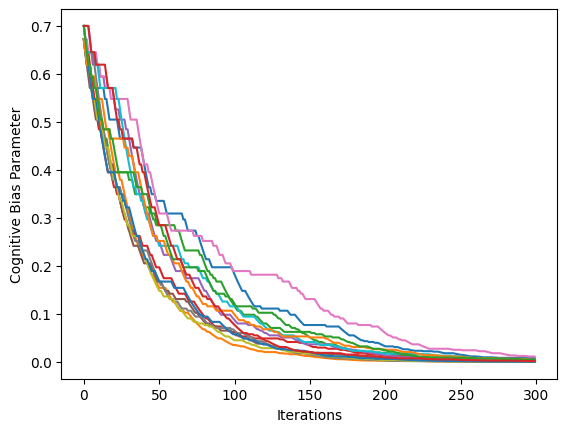

In [20]:
first_solver_aPSO.visualize_pso_adaptive()

## Car Sharing Route - PSO

### PSO (Non-adaptive)

In [21]:
first_map_PSO= first_solver_PSO.visualize_solution(route_color="blue",prefix="A")
second_map_PSO = second_solver_PSO.visualize_solution(route_color="green", m = first_map_SGA, prefix="B")
third_map_PSO = third_solver_PSO.visualize_solution(route_color="red", m=second_map_SGA, prefix="C")
third_map_PSO

### Adaptive PSO

In [22]:
first_map_aPSO= first_solver_PSO.visualize_solution(route_color="blue",prefix="A")
second_map_aPSO = second_solver_PSO.visualize_solution(route_color="green", m = first_map_SGA, prefix="B")
third_map_aPSO = third_solver_PSO.visualize_solution(route_color="red", m=second_map_SGA, prefix="C")
third_map_aPSO

## Algorithm Comparison

Text(0, 0.5, 'Maximum Profits')

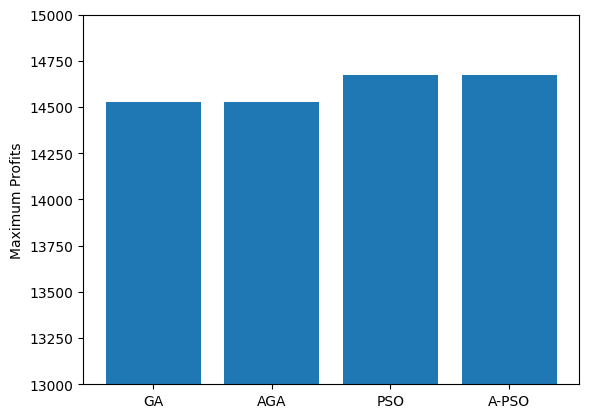

In [29]:
x_label = ['GA', 'AGA', 'PSO', 'A-PSO']
profits = [round(first_solver_SGA.solution_cost+second_solver_SGA.solution_cost+third_solver_SGA.solution_cost,2),
    round(first_solver_AGA.solution_cost+second_solver_AGA.solution_cost+third_solver_AGA.solution_cost,2),
    round(first_solver_PSO.gBest_cost+second_solver_PSO.gBest_cost+third_solver_PSO.gBest_cost,2),
    round(first_solver_aPSO.gBest_cost+second_solver_aPSO.gBest_cost+third_solver_aPSO.gBest_cost,2)]
plt.bar(x_label, profits)
plt.ylim([13000,15000])
plt.ylabel("Maximum Profits")


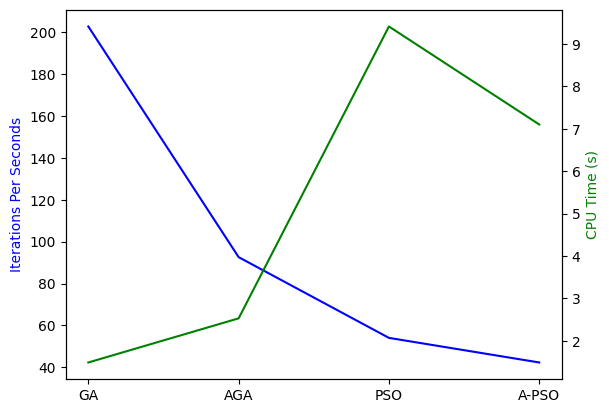

In [33]:
iter_per_second = [round(300/1.48,2), round(250/2.7,2), round(800/14.8,2), round(300/7.09,2)]
CPU_time = [1.49, 2.53, 9.41, 7.1]

fig, ax1 = plt.subplots()
ax2 = ax1.twinx()
ax2.plot(x_label, CPU_time, 'g-')
ax1.plot(x_label, iter_per_second, 'b-')

ax2.set_ylabel("CPU Time (s)", color='g')
ax1.set_ylabel('Iterations Per Seconds', color='b')

plt.show() 
        


**Note:** The observed CPU time and wall time were identical during the program execution.